<a href="https://colab.research.google.com/github/MazharZiadeh/gpu-nsga2-julia-fractals/blob/main/FRACTALS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!zip -r /content/all_content_files.zip /content/

gen	avg	min	max
1  	() 	() 	() 
2  	() 	() 	() 
3  	() 	() 	() 
4  	() 	() 	() 
5  	() 	() 	() 
6  	() 	() 	() 
7  	() 	() 	() 
8  	() 	() 	() 
9  	() 	() 	() 
10 	() 	() 	() 
11 	() 	() 	() 
12 	() 	() 	() 
13 	() 	() 	() 
14 	() 	() 	() 
15 	() 	() 	() 
16 	() 	() 	() 
17 	() 	() 	() 
18 	() 	() 	() 
19 	() 	() 	() 
20 	() 	() 	() 


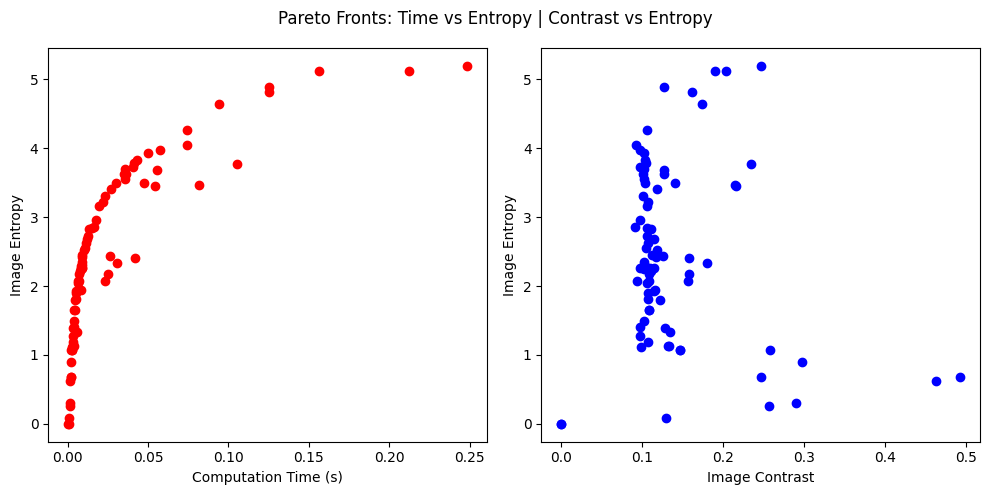

✅ Saved results to results/evolution_results.xlsx
✅ Saved combined image to results/combined_best_fractals.png


In [11]:
import random
import os
import matplotlib.pyplot as plt
import pandas as pd
from deap import base, creator, tools, algorithms
import time
import numpy as np
from scipy.stats import entropy

# === Choose your scenario here ===
scenario = "S3"  # Options: "S1", "S2", "S3"

params = {
    "S1": {"mu": 30, "lambda_": 70, "cxpb": 0.6, "mutpb": 0.4, "ngen": 30},
    "S2": {"mu": 70, "lambda_": 30, "cxpb": 0.9, "mutpb": 0.05, "ngen": 25},
    "S3": {"mu": 50, "lambda_": 50, "cxpb": 0.7, "mutpb": 0.2, "ngen": 20}
}[scenario]


def generate_julia(c: complex,
                   width: int,
                   height: int,
                   xlim: tuple[float, float],
                   ylim: tuple[float, float],
                   max_iter: int) -> np.ndarray:
    real = np.linspace(xlim[0], xlim[1], width)
    imag = np.linspace(ylim[0], ylim[1], height)
    Z = real[:, None] + 1j * imag[None, :]
    C = np.full_like(Z, c)
    M = np.zeros(Z.shape, dtype=int)
    mask = np.ones(Z.shape, bool)

    for i in range(max_iter):
        Z[mask] = Z[mask]**2 + C[mask]
        escaped = np.abs(Z) > 2
        M[mask & escaped] = i
        mask &= ~escaped
        if not mask.any():
            break

    return M


# === Define evaluation function ===
def eval_fractal(individual: list[float]) -> tuple[float, float, float]:
    """
    Evaluate a fractal individual.
    Each individual is a list of three parameters:
    - individual[0]: real part of complex c
    - individual[1]: imaginary part of complex c
    - individual[2]: zoom factor

    Returns a tuple with three objectives:
    - Maximize image entropy (complexity)
    - Maximize image contrast (sharpness)
    - Minimize computation time (speed)
    """
    c = complex(individual[0], individual[1])
    zoom = individual[2]
    width = height = 200

    xlim = (-1.5 / zoom, 1.5 / zoom)
    ylim = (-1.5 / zoom, 1.5 / zoom)
    max_iter = int(100 * zoom)

    start_time = time.time()
    M = generate_julia(c, width, height, xlim, ylim, max_iter)
    comp_time = time.time() - start_time

    # Normalize M to [0,1] for contrast calculation
    max_M = np.max(M)
    if max_M == 0:
        norm_M = M # Handle the case where max(M) is 0
    else:
        norm_M = M / max_M

    # Compute histogram entropy
    hist, _ = np.histogram(M, bins=range(max_iter + 2), density=True)
    img_entropy = entropy(hist + 1e-8)

    # Compute contrast (standard deviation of normalized intensities)
    img_contrast = np.std(norm_M)

    return img_entropy, img_contrast, comp_time

# === Fix DEAP redefinition error on re-run
from deap import creator
if "FitnessMulti" in creator.__dict__:
    del creator.FitnessMulti
if "Individual" in creator.__dict__:
    del creator.Individual

# === Setup NSGA-II
creator.create("FitnessMulti", base.Fitness, weights=(1.0, 1.0, -1.0))
creator.create("Individual", list, fitness=creator.FitnessMulti)

toolbox = base.Toolbox()
toolbox.register("attr_c_real", random.uniform, -1.0, 1.0)
toolbox.register("attr_c_imag", random.uniform, -1.0, 1.0)
toolbox.register("attr_zoom", random.uniform, 0.5, 5.0)
toolbox.register("individual", tools.initCycle, creator.Individual,
                 (toolbox.attr_c_real, toolbox.attr_c_imag, toolbox.attr_zoom), n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
# Now eval_fractal is defined when this line is reached
toolbox.register("evaluate", eval_fractal)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=0.2, indpb=0.2)
toolbox.register("select", tools.selNSGA2)

# === Use dynamic parameters from selected scenario
mu = params["mu"]
lambda_ = params["lambda_"]
cxpb = params["cxpb"]
mutpb = params["mutpb"]
ngen = params["ngen"]

pop = toolbox.population(n=mu)

logbook = tools.Logbook()
logbook.header = ['gen', 'avg', 'min', 'max']

class ParetoFrontWithGen(tools.ParetoFront):
    def update(self, population):
        super().update(population)
        current_gen = logbook[-1]['gen'] if logbook else 0
        for ind in self:
            if not hasattr(ind, 'generation'):
                ind.generation = current_gen

hof = ParetoFrontWithGen()

for gen in range(1, ngen + 1):
    offspring = algorithms.varOr(pop, toolbox, lambda_, cxpb=cxpb, mutpb=mutpb)

    invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
    fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    hof.update(offspring)

    pop[:] = toolbox.select(pop + offspring, mu)

    record = stats.compile(pop)
    logbook.record(gen=gen, **record)


print(logbook) # Optional: print the logbook

# === Plot results
front = [ind.fitness.values for ind in hof]
entropies = [f[0] for f in front]
contrasts = [f[1] for f in front]
times = [f[2] for f in front]

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(121)
ax.scatter(times, entropies, c='red')
ax.set_xlabel("Computation Time (s)")
ax.set_ylabel("Image Entropy")

ax2 = fig.add_subplot(122)
ax2.scatter(contrasts, entropies, c='blue')
ax2.set_xlabel("Image Contrast")
ax2.set_ylabel("Image Entropy")

plt.suptitle("Pareto Fronts: Time vs Entropy | Contrast vs Entropy")
plt.tight_layout()
plt.show()

# === Save results to folders
os.makedirs("best_fractals", exist_ok=True)
os.makedirs("results", exist_ok=True)

records = []
for ind in hof:
    record = {
        'c_real': ind[0],
        'c_imag': ind[1],
        'zoom': ind[2],
        'entropy': ind.fitness.values[0],
        'contrast': ind.fitness.values[1],
        'compute_time': ind.fitness.values[2],
        'generation': getattr(ind, 'generation', 'N/A') # Get generation or 'N/A'
    }
    records.append(record)

df = pd.DataFrame(records)
df.index.name = 'Index'
df.to_excel("results/evolution_results.xlsx", index=True)
print("✅ Saved results to results/evolution_results.xlsx")

# === Save best 20 fractal images
hof_sorted = sorted(hof, key=lambda ind: ind.fitness.values[0], reverse=True)

# Save the top 20 best images
num_images_to_save = 20
for idx, ind in enumerate(hof_sorted[:num_images_to_save]):
    c = complex(ind[0], ind[1])
    zoom = ind[2]
    M = generate_julia(c, 600, 600, (-1.5/zoom, 1.5/zoom), (-1.5/zoom, 1.5/zoom), int(100*zoom)) # Smaller size for combined image
    plt.figure(figsize=(6, 6))
    plt.imshow(M.T, cmap='inferno', extent=(-1.5/zoom, 1.5/zoom, -1.5/zoom, 1.5/zoom))
    plt.title(f"Best #{idx}: Entropy={ind.fitness.values[0]:.3f}, Contrast={ind.fitness.values[1]:.3f}")
    plt.axis('off')
    plt.savefig(f"best_fractals/best_fractal_{idx}.png", bbox_inches='tight', pad_inches=0.1, dpi=150) # Smaller DPI for combined image
    plt.close()

# === Create combined image
from PIL import Image

def create_combined_image(image_folder, num_images, grid_rows, grid_cols, output_filename):
    images = []
    for i in range(num_images):
        try:
            img_path = os.path.join(image_folder, f"best_fractal_{i}.png")
            images.append(Image.open(img_path))
        except FileNotFoundError:
            print(f"Warning: Image {img_path} not found. Skipping.")
            continue

    if not images:
        print("No images found to combine.")
        return

    # Assuming all images have the same size after saving
    img_width, img_height = images[0].size

    # Calculate the size of the combined image
    combined_width = grid_cols * img_width
    combined_height = grid_rows * img_height

    combined_img = Image.new('RGB', (combined_width, combined_height))

    # Paste images into the grid
    img_index = 0
    for row in range(grid_rows):
        for col in range(grid_cols):
            if img_index < len(images):
                combined_img.paste(images[img_index], (col * img_width, row * img_height))
                img_index += 1
            else:
                break # Stop if we run out of images

    combined_img.save(output_filename)
    print(f"✅ Saved combined image to {output_filename}")

# Parameters for the combined image
num_best_images_to_combine = 20
grid_rows = 4
grid_cols = 5
combined_output_filename = "results/combined_best_fractals.png"

create_combined_image("best_fractals", num_best_images_to_combine, grid_rows, grid_cols, combined_output_filename)

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import euclidean
from sklearn.preprocessing import MinMaxScaler
import os

# Load the uploaded Excel file
file_path = "/content/results/evolution_results.xlsx"
df = pd.read_excel(file_path, index_col=0)

# Normalize entropy, contrast (maximize), and compute_time (minimize => invert and normalize)
df_norm = df.copy()
scaler = MinMaxScaler()

df_norm[['entropy', 'contrast']] = scaler.fit_transform(df[['entropy', 'contrast']])
df_norm['compute_time'] = 1 - scaler.fit_transform(df[['compute_time']])  # Invert for maximization logic

# === Plot Normalized Pareto Front 1: Time vs Entropy ===
os.makedirs("results2", exist_ok=True)
plt.figure(figsize=(6, 5))
plt.scatter(df_norm['compute_time'], df_norm['entropy'], c='red')
plt.xlabel("Normalized Computation Time (maximized)")
plt.ylabel("Normalized Image Entropy")
plt.title("Normalized Pareto: Time vs Entropy")
plt.grid(True)
plt.tight_layout()
plt.savefig("results/normalized_pareto_time_entropy.png", dpi=300)
plt.close()

# === Plot Normalized Pareto Front 2: Contrast vs Entropy ===
plt.figure(figsize=(6, 5))
plt.scatter(df_norm['contrast'], df_norm['entropy'], c='blue')
plt.xlabel("Normalized Image Contrast")
plt.ylabel("Normalized Image Entropy")
plt.title("Normalized Pareto: Contrast vs Entropy")
plt.grid(True)
plt.tight_layout()
plt.savefig("results/normalized_pareto_contrast_entropy.png", dpi=300)
plt.close()

# === Spread Metric Calculation ===
def compute_spread_metric(pareto_points):
    pareto_points = np.array(pareto_points)
    pareto_points = pareto_points[np.argsort(pareto_points[:, 0])]
    distances = [euclidean(p1, p2) for p1, p2 in zip(pareto_points[:-1], pareto_points[1:])]
    d_bar = np.mean(distances)
    delta = sum(abs(d - d_bar) for d in distances) / (len(distances) * d_bar) if d_bar != 0 else 0
    return delta

spread_time_entropy = compute_spread_metric(df_norm[['compute_time', 'entropy']].values)
spread_contrast_entropy = compute_spread_metric(df_norm[['contrast', 'entropy']].values)

# Save spread metric
with open("results/spread_metrics.txt", "w") as f:
    f.write(f"Spread (Time vs Entropy): {spread_time_entropy:.4f}\n")
    f.write(f"Spread (Contrast vs Entropy): {spread_contrast_entropy:.4f}\n")

# === Convergence Plot (if generation info exists) ===
if 'generation' in df.columns:
    df_grouped = df.groupby('generation').agg({
        'entropy': 'mean',
        'contrast': 'mean',
        'compute_time': 'mean'
    }).reset_index()

    plt.figure(figsize=(10, 6))
    plt.plot(df_grouped['generation'], df_grouped['entropy'], label='Entropy')
    plt.plot(df_grouped['generation'], df_grouped['contrast'], label='Contrast')
    plt.plot(df_grouped['generation'], df_grouped['compute_time'], label='Compute Time')
    plt.xlabel("Generation")
    plt.ylabel("Objective Value")
    plt.title("Convergence Over Generations")
    plt.legend()
    plt.grid(True)
    plt.savefig("results/convergence_over_generations.png", dpi=300)
    plt.close()

df_norm.head(10)


,c_real,c_imag,zoom,entropy,contrast,compute_time,generation
Index,,,,,,,
0,0.199996,0.553355,3.914018,1.000000,0.460624,0.510894,14
1,-0.342367,0.612092,4.339928,0.999648,0.500632,0.522827,16
2,-0.221955,0.651401,4.549273,0.982193,0.359969,0.594385,13
3,0.080320,-0.617548,4.452884,0.978075,0.543743,0.325670,15
4,-0.740736,-0.158008,3.755298,0.940008,0.345457,0.695600,17
5,-0.682007,-0.318058,3.965739,0.916262,0.290211,0.700799,4
6,-0.458290,0.563470,3.957265,0.912258,0.269965,0.735942,14
7,0.373594,-0.363008,3.545533,0.895146,0.383827,0.541108,11
8,0.105941,-0.627617,2.573833,0.874375,0.387118,0.767174,18


In [5]:
!pip install numpy matplotlib pandas deap scipy scikit-learn pillow ace_tools
